In [37]:
'''
            UŻYCIE AI

Kod został napisany z wykorzystaniem 
generatywnej AI. Autorzy zweryfikowali
wszystko i prezentują własny wkład intelektualny,
biorąc pełną odpowiedzialność za ostateczną postać pracy
'''

'\n            UŻYCIE AI\n\nKod został napisany z wykorzystaniem \ngeneratywnej AI. Autorzy zweryfikowali\nwszystko i prezentują własny wkład intelektualny,\nbiorąc pełną odpowiedzialność za ostateczną postać pracy\n'

In [38]:
# dropna przy value_counts można usunąć, bo jest sprawdzone wcześniej
# zrobienie odpowiednich wartosci w polach mozna zrobic od razu przy 
#     wczytywaniu, zamiast potem sprawdzac i usuwac

In [39]:
import numpy as np
import pandas as pd

In [40]:
# wczytanie lookupu stref
zones = pd.read_csv("taxi_zone_lookup.csv")

# zostawiamy tylko strefy z Manhattanu
manhattan_zones = zones.loc[zones["Borough"] == "Manhattan", "LocationID"].tolist()

manhattan_zones;

In [41]:
''' 
    WCZYTANIE FHV. FITLROWANIE. 
    
    Wyrzucamy kolumny "dispatching_base_num",
        "originating_base_num", "driver_pay".
    Zostawiamy tylko te przejazdy, które:
    - zaczynają i kończą się na Manhattanie. 
    - są zwykłe (NIE wav, shared, access)
    - mają dodatnie / nieujemne wartości w 
        polach gdzie inne nie mają sensu
'''

fhv = (pd.read_parquet("fhvhv_tripdata_2025-01.parquet")
      .drop(columns = ["dispatching_base_num", "originating_base_num",
                       "driver_pay"])
      .query('PULocationID in @manhattan_zones and '
             'DOLocationID in @manhattan_zones and '
             'wav_request_flag == "N" and '
             'shared_request_flag == "N" and '
             'shared_match_flag == "N" and '
             'access_a_ride_flag == "N" and '
             'trip_miles > 0 and '
             'trip_time > 0 and '
             'base_passenger_fare > 0 and '
             'tolls >= 0 and '
             'bcf >= 0 and '
             'sales_tax >= 0 and '
             'congestion_surcharge >= 0 and '
             'airport_fee >= 0 and '
             'tips >= 0 and '
             'cbd_congestion_fee >= 0') 
      )

In [42]:
fhv;

In [43]:
# Sprawdzamy czy są jakieś brakujące wartości
fhv.isna().sum()

hvfhs_license_num             0
request_datetime              0
on_scene_datetime       1503304
pickup_datetime               0
dropoff_datetime              0
PULocationID                  0
DOLocationID                  0
trip_miles                    0
trip_time                     0
base_passenger_fare           0
tolls                         0
bcf                           0
sales_tax                     0
congestion_surcharge          0
airport_fee                   0
tips                          0
shared_request_flag           0
shared_match_flag             0
access_a_ride_flag            0
wav_request_flag              0
wav_match_flag                0
cbd_congestion_fee            0
dtype: int64

In [44]:
# Sprawdzamy jak wyglądają rekordy z NA
fhv[fhv["on_scene_datetime"].isna()]

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,...,sales_tax,congestion_surcharge,airport_fee,tips,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
1,HV0005,2025-01-01 00:18:33,NaT,2025-01-01 00:29:49,2025-01-01 00:41:52,127,244,3.313,723,16.97,...,1.51,0.00,0.0,0.00,N,N,N,N,N,0.0
8,HV0005,2025-01-01 00:10:48,NaT,2025-01-01 00:12:35,2025-01-01 00:51:37,234,41,7.254,2342,33.49,...,2.86,2.75,0.0,0.00,N,N,N,N,N,0.0
10,HV0005,2025-01-01 00:02:47,NaT,2025-01-01 00:06:32,2025-01-01 00:17:04,141,239,2.095,632,12.57,...,1.11,2.75,0.0,3.36,N,N,N,N,N,0.0
11,HV0005,2025-01-01 00:10:09,NaT,2025-01-01 00:19:16,2025-01-01 00:28:49,239,166,2.876,573,11.86,...,1.05,2.75,0.0,0.00,N,N,N,N,N,0.0
12,HV0005,2025-01-01 00:21:56,NaT,2025-01-01 00:32:52,2025-01-01 00:39:49,166,116,1.100,417,11.87,...,1.05,0.00,0.0,0.00,N,N,N,N,N,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20405582,HV0005,2025-01-31 23:57:17,NaT,2025-01-31 23:59:47,2025-02-01 00:07:22,68,48,1.112,455,12.04,...,1.09,2.75,0.0,0.00,N,N,N,N,N,1.5
20405626,HV0005,2025-01-31 23:03:49,NaT,2025-01-31 23:12:24,2025-01-31 23:26:12,233,48,1.821,828,17.61,...,1.56,2.75,0.0,2.00,N,N,N,N,N,1.5
20405627,HV0005,2025-01-31 23:27:33,NaT,2025-01-31 23:31:32,2025-01-31 23:35:55,164,164,0.678,263,7.30,...,0.68,2.75,0.0,0.00,N,N,N,N,N,1.5
20405628,HV0005,2025-01-31 23:31:25,NaT,2025-01-31 23:40:41,2025-01-31 23:58:55,234,125,2.603,1094,18.58,...,0.00,0.00,0.0,0.00,N,N,N,N,N,0.0


In [45]:
# Wychodzi ze po prostu Lyft (HV0005) nie ma on_scene_datetime
fhv[fhv["on_scene_datetime"].isna()]["hvfhs_license_num"].unique()

array(['HV0005'], dtype=object)

In [46]:
# Sprawdzamy wartości congestion_surcharge
fhv["congestion_surcharge"].value_counts(dropna=False)

congestion_surcharge
2.75    4820175
0.00     541682
0.75        666
5.50          2
Name: count, dtype: int64

In [47]:
# Sprawdzamy rekordy z wartościami 0.75, 3.5 i 5.50
display(fhv[fhv["congestion_surcharge"] == 0.75])
display(fhv[fhv["congestion_surcharge"] == 3.5])
display(fhv[fhv["congestion_surcharge"] == 5.50])
fhv[fhv["congestion_surcharge"].isin([0.75, 3.5, 5.50])]["hvfhs_license_num"].unique()

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,...,sales_tax,congestion_surcharge,airport_fee,tips,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
12231,HV0003,2025-01-01 00:17:10,2025-01-01 00:20:20,2025-01-01 00:22:20,2025-01-01 00:36:58,234,170,1.50,878,21.11,...,1.88,0.75,0.0,0.00,N,N,N,N,Y,0.0
20072,HV0003,2025-01-01 00:11:10,2025-01-01 00:15:52,2025-01-01 00:17:53,2025-01-01 00:50:35,162,186,1.92,1962,42.72,...,3.78,0.75,0.0,0.00,N,N,N,N,N,0.0
108135,HV0003,2025-01-01 01:20:00,2025-01-01 01:15:17,2025-01-01 01:16:14,2025-01-01 01:26:38,107,162,1.40,624,14.46,...,1.29,0.75,0.0,0.00,N,N,N,N,Y,0.0
239855,HV0003,2025-01-01 04:24:05,2025-01-01 04:28:05,2025-01-01 04:29:07,2025-01-01 04:32:36,100,162,0.66,209,26.04,...,2.31,0.75,0.0,0.00,N,N,N,N,N,0.0
285880,HV0003,2025-01-01 06:35:20,2025-01-01 06:47:18,2025-01-01 06:48:05,2025-01-01 06:52:05,48,48,0.01,240,20.80,...,1.85,0.75,0.0,2.39,N,N,N,N,Y,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20081518,HV0003,2025-01-31 16:32:11,2025-01-31 16:42:35,2025-01-31 16:43:47,2025-01-31 17:07:40,68,87,5.15,1433,59.13,...,5.25,0.75,0.0,0.00,N,N,N,N,N,1.5
20146865,HV0003,2025-01-31 18:00:35,2025-01-31 18:13:57,2025-01-31 18:15:58,2025-01-31 18:39:15,13,68,3.94,1397,33.76,...,3.00,0.75,0.0,0.00,N,N,N,N,N,1.5
20278579,HV0003,2025-01-31 21:13:32,2025-01-31 21:20:22,2025-01-31 21:22:23,2025-01-31 21:38:11,164,158,1.73,948,28.19,...,2.53,0.75,0.0,3.25,N,N,N,N,N,1.5
20305430,HV0003,2025-01-31 21:13:32,2025-01-31 21:20:19,2025-01-31 21:22:19,2025-01-31 21:39:30,164,158,1.72,1031,28.70,...,2.69,0.75,0.0,5.20,N,N,N,N,Y,1.5


,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,...,sales_tax,congestion_surcharge,airport_fee,tips,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee


,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,...,sales_tax,congestion_surcharge,airport_fee,tips,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
14177502,HV0005,2025-01-22 21:08:31,NaT,2025-01-22 21:21:17,2025-01-22 21:35:11,161,137,1.589,834,24.26,...,2.32,5.5,0.0,0.0,N,N,N,N,N,3.0
18280073,HV0005,2025-01-28 21:02:06,NaT,2025-01-28 21:06:23,2025-01-28 21:13:58,90,186,0.999,455,15.44,...,1.86,5.5,0.0,0.0,N,N,N,N,N,3.0


array(['HV0003', 'HV0005'], dtype=object)

In [48]:
'''
    Rekordy nie wydają się uszkodzone, ale usuwamy je, 
    bo analizujemy tylko nie sharowane przejazdy, dla
    którch congestion_surcharge powinien być 0 lub 2,75
    https://www.nyc.gov/site/tlc/about/congestion-surcharge.page
'''

fhv = fhv[~fhv["congestion_surcharge"].isin([0.75, 3.5, 5.5])]

In [49]:
fhv["congestion_surcharge"].value_counts()

congestion_surcharge
2.75    4820175
0.00     541682
Name: count, dtype: int64

In [50]:
# Sprawdzamy wartości cbd_congestion_fee
fhv["cbd_congestion_fee"].value_counts(dropna=False)
# zgadzają się https://congestionreliefzone.mta.info/tolling

cbd_congestion_fee
1.5    3776677
0.0    1585180
Name: count, dtype: int64

In [51]:
# Sprawdzamy wartości airport_fee
fhv["airport_fee"].value_counts()

airport_fee
0.0    5361857
Name: count, dtype: int64

In [52]:
# Usuwamy niezerowe
fhv = fhv[fhv["airport_fee"] == 0]
fhv["airport_fee"].value_counts()

airport_fee
0.0    5361857
Name: count, dtype: int64

In [53]:
# Sprawdzamy wartości base_passenger_fare
print(fhv["base_passenger_fare"].value_counts().sort_index())
#print(fhv["base_passenger_fare"].value_counts().sort_index().head(10))
#print(fhv["base_passenger_fare"].value_counts().sort_index().tail(10))
# wszystkie wydają się mieć sens teoretyczny, ale 

base_passenger_fare
0.01       2
0.02       4
0.03       3
0.04       3
0.05       3
          ..
673.07     1
766.69     1
820.67     1
1173.11    1
1210.97    1
Name: count, Length: 12568, dtype: int64


In [54]:
# Sprawdzamy rozkład do przedziałów
mniej_3 = (fhv["base_passenger_fare"] < 3).sum()
miedzy_3_85 = ((fhv["base_passenger_fare"] >= 3) & 
              (fhv["base_passenger_fare"] <= 85)).sum()
miedzy_85_150 = ((fhv["base_passenger_fare"] > 85) & 
                (fhv["base_passenger_fare"] <= 150)).sum()
wieksze_150 = (fhv["base_passenger_fare"] > 150).sum()

print('"< 3": ', mniej_3)
print('"<3 ; 85>" :', miedzy_3_85)
print('(85 ; 150>" :', miedzy_85_150)
print('"> 150": ', wieksze_150)
# do sprawdzenia czy zaburzaja oszacowanie i ew. usunięcia

"< 3":  742
"<3 ; 85>" : 5351676
(85 ; 150>" : 8736
"> 150":  703


In [55]:
# Sprawdzamy wartości trip_miles
fhv["trip_miles"].value_counts().sort_index()
# wszystkie wydają się mieć sens teoretyczny, ale 

trip_miles
0.007       12
0.010      331
0.011        1
0.013        1
0.016        1
          ... 
120.040      1
140.807      1
156.060      1
166.470      1
212.770      1
Name: count, Length: 14740, dtype: int64

In [56]:
# Sprawdzamy rozkład do przedziałów
mniej_02 = (fhv["trip_miles"] < 0.2).sum()
miedzy_02_20 = ((fhv["trip_miles"] >= 0.2) & 
              (fhv["trip_miles"] <= 20)).sum()
miedzy_20_35 = ((fhv["trip_miles"] > 20) & 
                (fhv["trip_miles"] <= 35)).sum()
wieksze_35 = (fhv["trip_miles"] > 35).sum()

print('"< 0.2": ', mniej_02)
print('"<0.2 ; 20>" :', miedzy_02_20)
print('(20 ; 35>" :', miedzy_20_35)
print('"> 35": ', wieksze_35)
# do sprawdzenia czy zaburzaja oszacowanie i ew. usunięcia

"< 0.2":  4115
"<0.2 ; 20>" : 5356635
(20 ; 35>" : 797
"> 35":  310


In [57]:
# Sprawdzamy wartości trip_time
fhv["trip_time"].value_counts().sort_index()
# wszystkie wydają się mieć sens teoretyczny, ale 

trip_time
1        14
7         2
8         2
10        4
11        3
         ..
16389     1
16631     1
18435     1
19519     1
25412     1
Name: count, Length: 5315, dtype: int64

In [58]:
# Sprawdzamy rozkład do przedziałów
mniej_60 = (fhv["trip_time"] < 60).sum()
miedzy_60_1800 = ((fhv["trip_time"] >= 60) & 
                 (fhv["trip_time"] <= 1800)).sum()
miedzy_1800_2700 = ((fhv["trip_time"] > 1800) & 
                   (fhv["trip_time"] <= 2700)).sum()
wieksze_2700 = (fhv["trip_time"] > 2700).sum()

print('"< 60": ', mniej_60)
print('"<60 ; 1800>" :', miedzy_60_1800)
print('(1800 ; 2700>" :', miedzy_1800_2700)
print('"> 2700": ', wieksze_2700)
# do sprawdzenia czy zaburzaja oszacowanie i ew. usunięcia

"< 60":  298
"<60 ; 1800>" : 5169798
(1800 ; 2700>" : 177219
"> 2700":  14542


In [59]:
# Sprawdzamy liczbę ,,sensownych'' i nie
mask = (fhv["base_passenger_fare"].between(3, 85) &
        fhv["trip_miles"].between(0.2, 35) &
        fhv["trip_time"].between(60, 2700))

print("sensowne: ", mask.sum()) 
print("bezsensowne: ", (~mask).sum())
# prawie wszystkie mają sens, reszta do sprawdzenia

sensowne:  5335357
bezsensowne:  26500


In [60]:
# Wstępnie przefiltrowane dane zapisujemy do porównań
#fhv_wstępne = fhv.copy()

In [61]:
'''
    TERAZ, PO WSTĘPNYM PRZEFILITROWANIU DANYCH I
    OKREŚLENIU, ŻE WSZYSTKIE MAJĄ SENS TEORETYCZNY,
    A ZDECYDOWANA WIĘKSZOŚC TAKŻE SENS REALNY,
    MOŻEMY PRZEJŚĆ DO ANALIZY JUŻ W PODZIALE NA 
    FIRMY (UBER, LYFT), ORAZ DO SPRAWDZANIA JAK
    SOBIE PORADZĄ W MODELU EKONOMETRYCZNYM, A W 
    SZCZEGÓLNOŚCI CZY BĘDĄ OBSERWACJE ZABURZAJĄCE,
    KTÓRYMI BĘDZIE SIĘ TRZEBA WÓWCZAS ZAJĄĆ
'''

'\n    TERAZ, PO WSTĘPNYM PRZEFILITROWANIU DANYCH I\n    OKREŚLENIU, ŻE WSZYSTKIE MAJĄ SENS TEORETYCZNY,\n    A ZDECYDOWANA WIĘKSZOŚC TAKŻE SENS REALNY,\n    MOŻEMY PRZEJŚĆ DO ANALIZY JUŻ W PODZIALE NA \n    FIRMY (UBER, LYFT), ORAZ DO SPRAWDZANIA JAK\n    SOBIE PORADZĄ W MODELU EKONOMETRYCZNYM, A W \n    SZCZEGÓLNOŚCI CZY BĘDĄ OBSERWACJE ZABURZAJĄCE,\n    KTÓRYMI BĘDZIE SIĘ TRZEBA WÓWCZAS ZAJĄĆ\n'

In [62]:
fhv;

In [63]:
# Wyciągamy z pickup_datetime godzinę i dzień tygodnia
fhv = fhv.assign(hour = fhv["pickup_datetime"].dt.hour,
                 weekday = fhv["pickup_datetime"].dt.weekday,
                 month = fhv["pickup_datetime"].dt.month)
# weekday 0 to poniedziałek

In [64]:
fhv

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,...,tips,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee,hour,weekday,month
0,HV0003,2025-01-01 00:28:07,2025-01-01 00:31:17,2025-01-01 00:33:25,2025-01-01 00:54:24,148,211,1.320,1259,18.21,...,0.00,N,N,N,N,N,0.0,0,2,1
1,HV0005,2025-01-01 00:18:33,NaT,2025-01-01 00:29:49,2025-01-01 00:41:52,127,244,3.313,723,16.97,...,0.00,N,N,N,N,N,0.0,0,2,1
8,HV0005,2025-01-01 00:10:48,NaT,2025-01-01 00:12:35,2025-01-01 00:51:37,234,41,7.254,2342,33.49,...,0.00,N,N,N,N,N,0.0,0,2,1
10,HV0005,2025-01-01 00:02:47,NaT,2025-01-01 00:06:32,2025-01-01 00:17:04,141,239,2.095,632,12.57,...,3.36,N,N,N,N,N,0.0,0,2,1
11,HV0005,2025-01-01 00:10:09,NaT,2025-01-01 00:19:16,2025-01-01 00:28:49,239,166,2.876,573,11.86,...,0.00,N,N,N,N,N,0.0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20405653,HV0003,2025-01-31 23:41:20,2025-01-31 23:44:35,2025-01-31 23:45:11,2025-01-31 23:57:52,243,243,1.370,761,10.09,...,0.00,N,N,N,N,N,0.0,23,4,1
20405658,HV0003,2025-01-31 23:11:26,2025-01-31 23:12:17,2025-01-31 23:13:46,2025-01-31 23:20:56,249,79,0.720,430,27.11,...,3.29,N,N,N,N,N,1.5,23,4,1
20405659,HV0003,2025-01-31 23:24:02,2025-01-31 23:25:37,2025-01-31 23:26:04,2025-01-31 23:32:12,114,113,0.800,368,20.89,...,0.00,N,N,N,N,N,1.5,23,4,1
20405660,HV0003,2025-01-31 23:40:08,2025-01-31 23:41:09,2025-01-31 23:42:21,2025-01-31 23:48:20,114,144,0.630,359,31.78,...,0.00,N,N,N,N,N,1.5,23,4,1


In [65]:
fhv['month'].value_counts()

month
1    5361857
Name: count, dtype: int64

In [66]:
# Dodajemy kolumnę z opłatą całkowitą
fhv["total_amount"] = (fhv["base_passenger_fare"] + fhv["tolls"] +
                       fhv["bcf"] + fhv["sales_tax"] + 
                       fhv["congestion_surcharge"] +
                       fhv["cbd_congestion_fee"])

In [67]:
fhv

,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,...,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee,hour,weekday,month,total_amount
0,HV0003,2025-01-01 00:28:07,2025-01-01 00:31:17,2025-01-01 00:33:25,2025-01-01 00:54:24,148,211,1.320,1259,18.21,...,N,N,N,N,N,0.0,0,2,1,22.92
1,HV0005,2025-01-01 00:18:33,NaT,2025-01-01 00:29:49,2025-01-01 00:41:52,127,244,3.313,723,16.97,...,N,N,N,N,N,0.0,0,2,1,18.95
8,HV0005,2025-01-01 00:10:48,NaT,2025-01-01 00:12:35,2025-01-01 00:51:37,234,41,7.254,2342,33.49,...,N,N,N,N,N,0.0,0,2,1,39.99
10,HV0005,2025-01-01 00:02:47,NaT,2025-01-01 00:06:32,2025-01-01 00:17:04,141,239,2.095,632,12.57,...,N,N,N,N,N,0.0,0,2,1,16.78
11,HV0005,2025-01-01 00:10:09,NaT,2025-01-01 00:19:16,2025-01-01 00:28:49,239,166,2.876,573,11.86,...,N,N,N,N,N,0.0,0,2,1,15.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20405653,HV0003,2025-01-31 23:41:20,2025-01-31 23:44:35,2025-01-31 23:45:11,2025-01-31 23:57:52,243,243,1.370,761,10.09,...,N,N,N,N,N,0.0,23,4,1,11.11
20405658,HV0003,2025-01-31 23:11:26,2025-01-31 23:12:17,2025-01-31 23:13:46,2025-01-31 23:20:56,249,79,0.720,430,27.11,...,N,N,N,N,N,1.5,23,4,1,34.46
20405659,HV0003,2025-01-31 23:24:02,2025-01-31 23:25:37,2025-01-31 23:26:04,2025-01-31 23:32:12,114,113,0.800,368,20.89,...,N,N,N,N,N,1.5,23,4,1,27.52
20405660,HV0003,2025-01-31 23:40:08,2025-01-31 23:41:09,2025-01-31 23:42:21,2025-01-31 23:48:20,114,144,0.630,359,31.78,...,N,N,N,N,N,1.5,23,4,1,39.41


In [68]:
# Sprawdzamy czy dobrze się dodało
(fhv["total_amount"] < fhv["base_passenger_fare"]).sum()

np.int64(0)

In [69]:
# Usuwamy kolumny niepotrzebne do modelu
fhv = fhv.drop(columns = ["on_scene_datetime", "tolls", "bcf",
                          "sales_tax", "congestion_surcharge",
                          "airport_fee", "tips", "shared_request_flag",
                          "shared_match_flag", "access_a_ride_flag",
                          "wav_request_flag", "wav_match_flag", 
                          "cbd_congestion_fee", "request_datetime",
                          "dropoff_datetime",   #"pickup_datetime",
                          "PULocationID", "DOLocationID"]);

In [70]:
# Zmieniamy czas na minuty zamiast sekund
fhv["trip_time_mins"] = fhv["trip_time"]/60
#fhv = fhv.drop(columns = ["trip_time"])

In [71]:
fhv

,hvfhs_license_num,pickup_datetime,trip_miles,trip_time,base_passenger_fare,hour,weekday,month,total_amount,trip_time_mins
0,HV0003,2025-01-01 00:33:25,1.320,1259,18.21,0,2,1,22.92,20.983333
1,HV0005,2025-01-01 00:29:49,3.313,723,16.97,0,2,1,18.95,12.050000
8,HV0005,2025-01-01 00:12:35,7.254,2342,33.49,0,2,1,39.99,39.033333
10,HV0005,2025-01-01 00:06:32,2.095,632,12.57,0,2,1,16.78,10.533333
11,HV0005,2025-01-01 00:19:16,2.876,573,11.86,0,2,1,15.99,9.550000
...,...,...,...,...,...,...,...,...,...,...
20405653,HV0003,2025-01-31 23:45:11,1.370,761,10.09,23,4,1,11.11,12.683333
20405658,HV0003,2025-01-31 23:13:46,0.720,430,27.11,23,4,1,34.46,7.166667
20405659,HV0003,2025-01-31 23:26:04,0.800,368,20.89,23,4,1,27.52,6.133333
20405660,HV0003,2025-01-31 23:42:21,0.630,359,31.78,23,4,1,39.41,5.983333


In [72]:
# Eksportujemy fhv do csv
fhv.to_csv("fhv_do_statOp.csv", index = False)

In [33]:
'''# Dzielimy na firmy
lyft = (fhv[fhv["hvfhs_license_num"] == "HV0005"]
       .drop(columns = ["hvfhs_license_num"]))
uber = (fhv[fhv["hvfhs_license_num"] == "HV0003"]
       .drop(columns = ["hvfhs_license_num"]))
#display(lyft)
#display(uber)'''

In [34]:
'''# Eksportujemy pliki dla firm do csv
lyft.to_csv("lyft_do_statOp.csv", index = False)
uber.to_csv("uber_do_statOp.csv", index = False)'''

In [67]:
'''# WIZUALIZACJA DANYCH

# ROZKŁADY ZMIENNYCH

# histogramy
# lyft trip_time_mins histogram
lyft["trip_time_mins"].hist(bins=100)
#plt.xlim(0, 400)
plt.xlabel("trip_time_mins")
plt.ylabel("count")
plt.ticklabel_format(style="plain", axis="y")
plt.title("Lyft - trip_time_mins")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = axes[0, 0]
ax2 = axes[1, 0]
ax3 = axes[0, 1]
ax4 = axes[1, 1]

# lyft trip_time_mins ograniczony histogram
ax1.hist(lyft["trip_time_mins"],
         bins=100,
         edgecolor="black",
         linewidth=0.5)
ax1.set_xlim(0, 70)
ax1.set_xlabel("trip_time_mins")
ax1.set_ylabel("count")
ax1.ticklabel_format(style="plain", axis="y")
ax1.set_title("Lyft - trip_time_mins")
ax1.grid(False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
print(lyft["trip_time_mins"].value_counts().sort_index())

# lyft trip_miles ograniczony histogram
ax2.hist(lyft["trip_miles"],
         bins=100, 
         edgecolor="black",
         linewidth=0.5)
ax2.set_xlim(0, 20)
ax2.set_xlabel("trip_miles")
ax2.set_ylabel("count")
ax2.ticklabel_format(style="plain", axis="y")
ax2.set_title("Lyft - trip_miles")
ax2.grid(False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# uber trip_time_mins ograniczony histogram
ax3.hist(uber["trip_time_mins"],
         bins=120, 
         color = "orange",
         edgecolor="black",
         linewidth=0.5)
ax3.set_xlim(0, 80)
ax3.set_xlabel("trip_time_mins")
ax3.set_ylabel("count")
ax3.ticklabel_format(style="plain", axis="y")
ax3.set_title("Uber - trip_time_mins")
ax3.grid(False)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

# uber trip_miles ograniczony histogram
ax4.hist(uber["trip_miles"],
         bins=135, 
         color = "orange",
         edgecolor="black",
         linewidth=0.5)
ax4.set_xlim(0, 20)
ax4.set_xlabel("trip_miles")
ax4.set_ylabel("count")
ax4.ticklabel_format(style="plain", axis="y")
ax4.set_title("Uber - trip_miles")
ax4.grid(False)
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)

plt.savefig("histogramy.png", dpi=300, bbox_inches="tight")
plt.show()

# boxploty
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharey='row')

ax1 = axes[0]
ax2 = axes[1]

# pełne
ax1.boxplot(
    [lyft["trip_time_mins"],
     uber["trip_time_mins"]],
     tick_labels=["Lyft", "Uber"],
     vert=True)
#ax1.set_xticks([]) 
ax1.set_ylim(-5, 420)
#plt.ylabel("trip_time_mins")
#ax1.set_title("Lyft - trip_time_mins")
ax1.xaxis.tick_top()

# ograniczone
ax2.boxplot(
    [lyft["trip_time_mins"],
     uber["trip_time_mins"]],
     tick_labels=["Lyft", "Uber"],
     vert=True)
#ax2.set_xticks([]) 
ax2.set_ylim(-5, 35)
#plt.ylabel("trip_time_mins")
#ax2.set_title("Lyft - trip_time_mins")
ax2.xaxis.tick_top()

plt.savefig("boxploty.png", dpi=300, bbox_inches="tight")
plt.show()

# ZALEŻNOŚCI, KORELACJE

# scatterploty trip_time_mins vs trip_miles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax2 = axes[1]

# lyft trip_time_mins vs trip_miles scatterplot i korelacja
ax1.scatter(
    lyft["trip_time_mins"],
    lyft["trip_miles"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
)
ax1.set_xlabel("trip_time_mins")
ax1.set_xlim(0, 200)
ax1.set_ylabel("trip_miles")
ax1.set_ylim(0, 75)
ax1.set_title("Lyft: trip_time_mins vs trip_miles")
rho, p_value = spearmanr(lyft["trip_time_mins"], lyft["trip_miles"])
print(rho)
print(p_value)

# uber trip_time_mins vs trip_miles scatterplot i korelacja
plt.scatter(
    uber["trip_time_mins"],
    uber["trip_miles"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
    color = "orange",
    #edgecolors = "white",   # kolor obramowania
    #linewidths = 0.05,       # grubość obramowania
)
ax2.set_xlabel("trip_time_mins")
ax2.set_xlim(0, 200)
ax2.set_ylabel("trip_miles")
ax2.set_ylim(0, 75)
ax2.set_title("Uber: trip_time_mins vs trip_miles")
rho, p_value = spearmanr(uber["trip_time_mins"], uber["trip_miles"])
print(rho)
print(p_value)

plt.savefig("scatterplot_ttm_tm.png", dpi=300, bbox_inches="tight")
plt.show()

# scatterploty z base_passenger_fare
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = axes[0, 0]
ax2 = axes[1, 0]
ax3 = axes[0, 1]
ax4 = axes[1, 1]

# lyft trip_time_mins vs base_passenger_fare scatterplot i korelacja
ax1.scatter(
    lyft["trip_time_mins"],
    lyft["base_passenger_fare"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
)
ax1.set_xlabel("trip_time_mins")
ax1.set_xlim(0, 200)
ax1.set_ylabel("base_passenger_fare")
ax1.set_ylim(0, 400)
ax1.set_title("Lyft: trip_time_mins vs base_passenger_fare")
#ax1.savefig("scat_ttm_vs_bpf_lyft.png", dpi=300, bbox_inches="tight")
#ax1.show()
rho, p_value = spearmanr(lyft["trip_time_mins"], lyft["base_passenger_fare"])
print(rho)
print(p_value)

# lyft trip_miles vs base_passenger_fare scatterplot i korelacja
ax2.scatter(
    lyft["trip_miles"],
    lyft["base_passenger_fare"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
)
ax2.set_xlabel("trip_miles")
ax2.set_xlim(0, 100)
ax2.set_ylabel("base_passenger_fare")
ax2.set_ylim(0, 400)
ax2.set_title("Lyft: trip_miles vs base_passenger_fare")
#ax2.savefig("scat_tm_vs_bpf_lyft.png", dpi=300, bbox_inches="tight")
#ax2.show()
rho, p_value = spearmanr(lyft["trip_miles"], lyft["base_passenger_fare"])
print(rho)
print(p_value)

# uber trip_miles vs base_passenger_fare scatterplot i korelacja
ax3.scatter(
    uber["trip_time_mins"],
    uber["base_passenger_fare"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
    color = "orange"
)
ax3.set_xlabel("trip_time_mins")
ax3.set_xlim(0, 200)
ax3.set_ylabel("base_passenger_fare")
ax3.set_ylim(0, 400)
ax3.set_title("Uber: trip_time_mins vs base_passenger_fare")
#ax3.savefig("scat_ttm_vs_bpf_uber.png", dpi=300, bbox_inches="tight")
#ax3.show()
rho, p_value = spearmanr(uber["trip_time_mins"], uber["base_passenger_fare"])
print(rho)
print(p_value)

# uber trip_miles vs base_passenger_fare scatterplot i korelacja
ax4.scatter(
    uber["trip_miles"],
    uber["base_passenger_fare"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
    color = "orange"
)
ax4.set_xlabel("trip_miles")
ax4.set_xlim(0, 100)
ax4.set_ylabel("base_passenger_fare")
ax4.set_ylim(0, 400)
ax4.set_title("Uber: trip_miles vs base_passenger_fare")
#ax4.savefig("scat_tm_vs_bpf_uber.png", dpi=300, bbox_inches="tight")
#ax4.show()
rho, p_value = spearmanr(uber["trip_miles"], uber["base_passenger_fare"])
print(rho)
print(p_value)

plt.savefig("scatterploty_bpf.png", dpi=300, bbox_inches="tight")
plt.show()

# sprawdzenie ,,dziwnych'' rzeczy - 1 mila, kilkadziesiąt dolarów opłata
display(fhv[(fhv["trip_miles"] < 1) & (fhv["base_passenger_fare"] > 40)].head())

# heatmapy
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax2 = axes[1]

# lyft heatmap
heat_lyft = (
    lyft
    .groupby(["hour", "weekday"])["base_passenger_fare"]
    .median()
    .unstack())
heat_lyft.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print(heat_lyft.min().min())
#plt.figure(figsize=(14, 5))
sns.heatmap(
    heat_lyft,
    cmap = "magma_r",
    cbar = False,
    vmin = 10,
    vmax = 40,
    ax = ax1)
ax1.set_xlabel("Weekday")
ax1.set_ylabel("Hour")
#heat.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax1.set_title("Lyft")

# uber heatmap
heat_uber = (
    uber
    .groupby(["hour", "weekday"])["base_passenger_fare"]
    .median()
    .unstack())
heat_uber.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print(heat_uber.min().min())
#plt.figure(figsize=(14, 5))
sns.heatmap(
    heat_uber,
    cmap = "magma_r",
    cbar = False,
    vmin = 10,
    vmax = 40,
    ax = ax2)
ax2.set_xlabel("Weekday")
#ax2.set_ylabel("Hour")
ax2.set_ylabel("")
ax2.set_yticks([])
ax2.set_title("Uber")

cbar = fig.colorbar(
    axes[1].collections[0],
    ax = axes,
    location="right",
    shrink=0.9,
    label="Median base_passenger_fare"
)

plt.savefig("heatmapy.png", dpi=300, bbox_inches="tight")
plt.show()'''

'# WIZUALIZACJA DANYCH\n\n# ROZKŁADY ZMIENNYCH\n\n# histogramy\n# lyft trip_time_mins histogram\nlyft["trip_time_mins"].hist(bins=100)\n#plt.xlim(0, 400)\nplt.xlabel("trip_time_mins")\nplt.ylabel("count")\nplt.ticklabel_format(style="plain", axis="y")\nplt.title("Lyft - trip_time_mins")\nplt.show()\n\nfig, axes = plt.subplots(2, 2, figsize=(12, 10))\n\nax1 = axes[0, 0]\nax2 = axes[1, 0]\nax3 = axes[0, 1]\nax4 = axes[1, 1]\n\n# lyft trip_time_mins ograniczony histogram\nax1.hist(lyft["trip_time_mins"],\n         bins=100,\n         edgecolor="black",\n         linewidth=0.5)\nax1.set_xlim(0, 70)\nax1.set_xlabel("trip_time_mins")\nax1.set_ylabel("count")\nax1.ticklabel_format(style="plain", axis="y")\nax1.set_title("Lyft - trip_time_mins")\nax1.grid(False)\nax1.spines["top"].set_visible(False)\nax1.spines["right"].set_visible(False)\nprint(lyft["trip_time_mins"].value_counts().sort_index())\n\n# lyft trip_miles ograniczony histogram\nax2.hist(lyft["trip_miles"],\n         bins=100, \n   

In [ ]:
# ZAKOMENTOWANE KODY ROBIĄCE TO CO KOMÓRKA WYŻEJ,
#    ALE PODZIELONE (JEDEN TYP W KOMÓRCE)

In [19]:
# histogramy trip_time_mins i trip_miles
# lyft trip_time_mins histogram
'''lyft["trip_time_mins"].hist(bins=100)
#plt.xlim(0, 400)
plt.xlabel("trip_time_mins")
plt.ylabel("count")
plt.ticklabel_format(style="plain", axis="y")
plt.title("Lyft - trip_time_mins")
plt.show()'''
'''
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = axes[0, 0]
ax2 = axes[1, 0]
ax3 = axes[0, 1]
ax4 = axes[1, 1]

# lyft trip_time_mins ograniczony histogram
ax1.hist(lyft["trip_time_mins"],
         bins=100, 
         edgecolor="black",
         linewidth=0.5)
ax1.set_xlim(0, 70)
ax1.set_xlabel("trip_time_mins")
ax1.set_ylabel("count")
ax1.ticklabel_format(style="plain", axis="y")
ax1.set_title("Lyft - trip_time_mins")
ax1.grid(False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
#plt.savefig("hist_ttm_lyft.png", dpi=300, bbox_inches="tight")
#plt.show()
print(lyft["trip_time_mins"].value_counts().sort_index())

# lyft trip_miles ograniczony histogram
ax2.hist(lyft["trip_miles"],
         bins=100, 
         edgecolor="black",
         linewidth=0.5)
ax2.set_xlim(0, 20)
ax2.set_xlabel("trip_miles")
ax2.set_ylabel("count")
ax2.ticklabel_format(style="plain", axis="y")
ax2.set_title("Lyft - trip_miles")
ax2.grid(False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
#plt.savefig("hist_ttm_lyft.png", dpi=300, bbox_inches="tight")
#plt.show()

# uber trip_time_mins ograniczony histogram
ax3.hist(uber["trip_time_mins"],
         bins=120, 
         color = "orange",
         edgecolor="black",
         linewidth=0.5)
ax3.set_xlim(0, 80)
ax3.set_xlabel("trip_time_mins")
ax3.set_ylabel("count")
ax3.ticklabel_format(style="plain", axis="y")
ax3.set_title("Uber - trip_time_mins")
ax3.grid(False)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
#plt.savefig("hist_ttm_lyft.png", dpi=300, bbox_inches="tight")
#plt.show()

# uber trip_miles ograniczony histogram
ax4.hist(uber["trip_miles"],
         bins=135, 
         color = "orange",
         edgecolor="black",
         linewidth=0.5)
ax4.set_xlim(0, 20)
ax4.set_xlabel("trip_miles")
ax4.set_ylabel("count")
ax4.ticklabel_format(style="plain", axis="y")
ax4.set_title("Uber - trip_miles")
ax4.grid(False)
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
#plt.savefig("hist_ttm_lyft.png", dpi=300, bbox_inches="tight")
#plt.show()

plt.show()'''

'\nfig, axes = plt.subplots(2, 2, figsize=(12, 10))\n\nax1 = axes[0, 0]\nax2 = axes[1, 0]\nax3 = axes[0, 1]\nax4 = axes[1, 1]\n\n# lyft trip_time_mins ograniczony histogram\nax1.hist(lyft["trip_time_mins"],\n         bins=100, \n         edgecolor="black",\n         linewidth=0.5)\nax1.set_xlim(0, 70)\nax1.set_xlabel("trip_time_mins")\nax1.set_ylabel("count")\nax1.ticklabel_format(style="plain", axis="y")\nax1.set_title("Lyft - trip_time_mins")\nax1.grid(False)\nax1.spines["top"].set_visible(False)\nax1.spines["right"].set_visible(False)\n#plt.savefig("hist_ttm_lyft.png", dpi=300, bbox_inches="tight")\n#plt.show()\nprint(lyft["trip_time_mins"].value_counts().sort_index())\n\n# lyft trip_miles ograniczony histogram\nax2.hist(lyft["trip_miles"],\n         bins=100, \n         edgecolor="black",\n         linewidth=0.5)\nax2.set_xlim(0, 20)\nax2.set_xlabel("trip_miles")\nax2.set_ylabel("count")\nax2.ticklabel_format(style="plain", axis="y")\nax2.set_title("Lyft - trip_miles")\nax2.grid(Fa

In [60]:
'''print((fhv["trip_miles"] < 10).sum())
print((lyft["trip_miles"] < 10).sum())
print((uber["trip_miles"] < 10).sum())
print((fhv["trip_miles"] < 12.5).sum() / (fhv["trip_miles"] > 0).sum())
print(fhv.loc[fhv["trip_miles"] == 2, "trip_time_mins"].unique().min())
print(fhv.loc[fhv["trip_miles"] == 2, "trip_time_mins"].unique().max())'''

5322449
1494084
3828365
0.9985462126274535
4.166666666666667
47.75


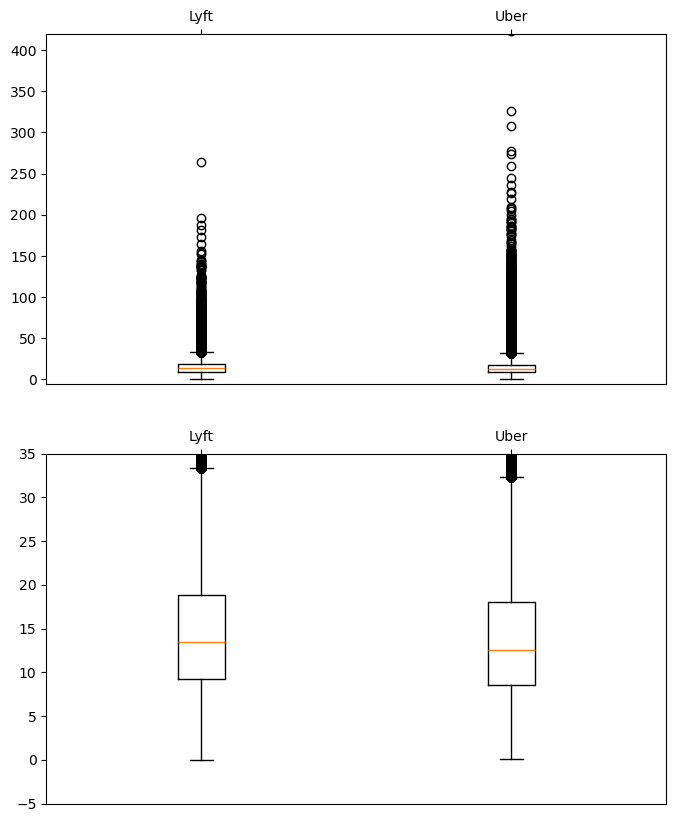

In [88]:
'''# boxploty
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharey='row')

ax1 = axes[0]
ax2 = axes[1]

ax1.boxplot(
    [lyft["trip_time_mins"],
     uber["trip_time_mins"]],
     tick_labels=["Lyft", "Uber"],
     vert=True)
#ax1.set_xticks([]) 
ax1.set_ylim(-5, 420)
#plt.ylabel("trip_time_mins")
#ax1.set_title("Lyft - trip_time_mins")
ax1.xaxis.tick_top()

ax2.boxplot(
    [lyft["trip_time_mins"],
     uber["trip_time_mins"]],
     tick_labels=["Lyft", "Uber"],
     vert=True)
#ax2.set_xticks([]) 
ax2.set_ylim(-5, 35)
#plt.ylabel("trip_time_mins")
#ax2.set_title("Lyft - trip_time_mins")
ax2.xaxis.tick_top()'''

0.811467434960142
0.0
0.8262152670189552
0.0


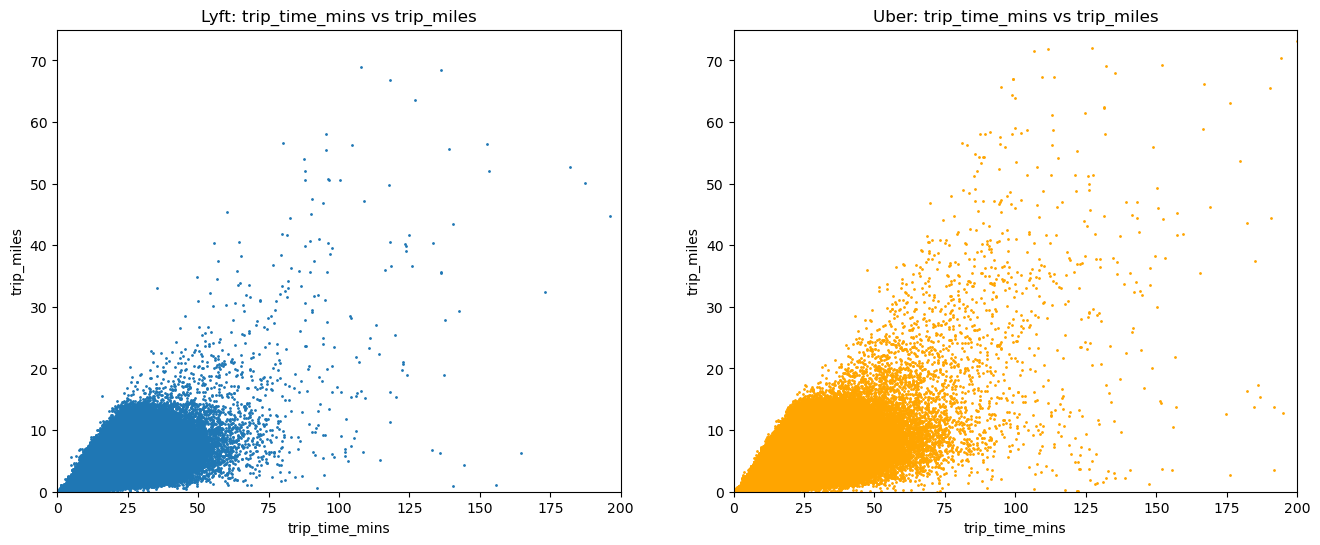

In [103]:
'''# scatterploty trip_time_mins vs trip_miles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax2 = axes[1]

# lyft trip_time_mins vs trip_miles scatterplot i korelacja
ax1.scatter(
    lyft["trip_time_mins"],
    lyft["trip_miles"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
)
ax1.set_xlabel("trip_time_mins")
ax1.set_xlim(0, 200)
ax1.set_ylabel("trip_miles")
ax1.set_ylim(0, 75)
ax1.set_title("Lyft: trip_time_mins vs trip_miles")
rho, p_value = spearmanr(lyft["trip_time_mins"], lyft["trip_miles"])
print(rho)
print(p_value)

# uber trip_time_mins vs trip_miles scatterplot i korelacja
plt.scatter(
    uber["trip_time_mins"],
    uber["trip_miles"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
    color = "orange",
    #edgecolors = "white",   # kolor obramowania
    #linewidths = 0.05,       # grubość obramowania
)
ax2.set_xlabel("trip_time_mins")
ax2.set_xlim(0, 200)
ax2.set_ylabel("trip_miles")
ax2.set_ylim(0, 75)
ax2.set_title("Uber: trip_time_mins vs trip_miles")
rho, p_value = spearmanr(uber["trip_time_mins"], uber["trip_miles"])
print(rho)
print(p_value)

plt.show()'''

0.8322847882246108
0.0
0.8271672182235316
0.0
0.7661237828690994
0.0
0.7174056352362866
0.0


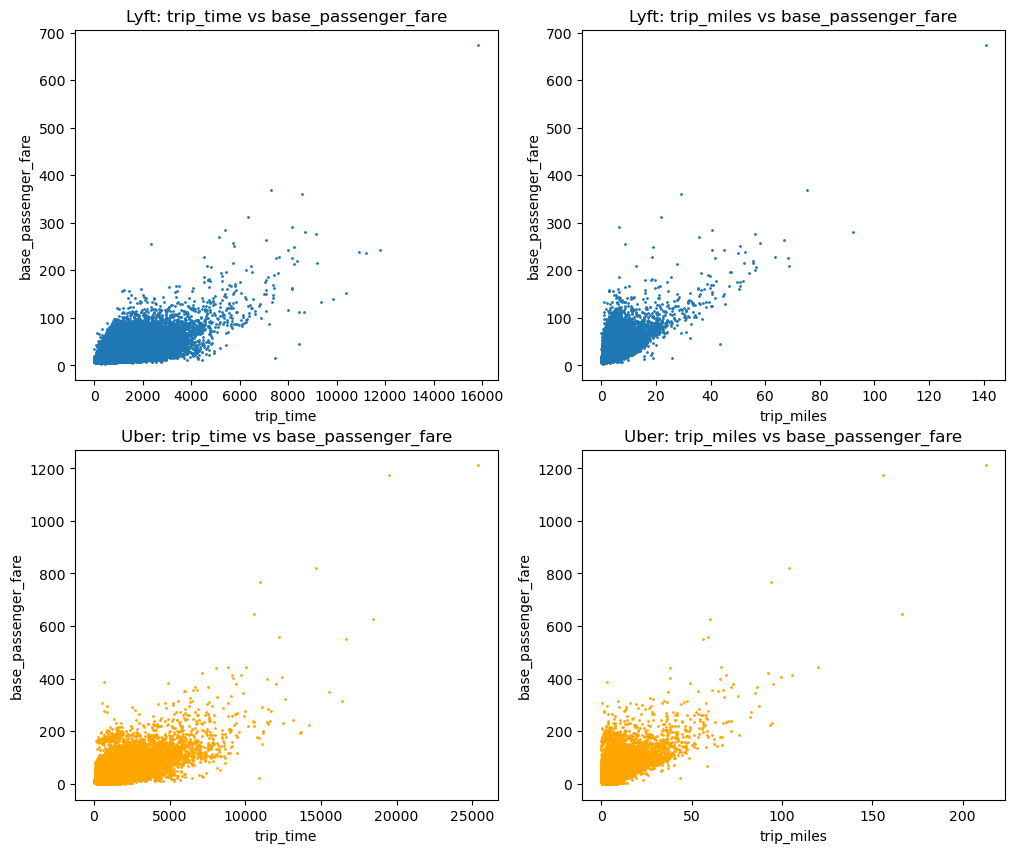

In [22]:
'''# scatterploty z base_passenger_fare
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

# lyft trip_time_mins vs base_passenger_fare scatterplot i korelacja
ax1.scatter(
    lyft["trip_time"],
    lyft["base_passenger_fare"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
)
ax1.set_xlabel("trip_time")
#ax1.set_xlim(0, 200)
ax1.set_ylabel("base_passenger_fare")
#ax1.set_ylim(0, 400)
ax1.set_title("Lyft: trip_time vs base_passenger_fare")
#ax1.savefig("scat_ttm_vs_bpf_lyft.png", dpi=300, bbox_inches="tight")
#ax1.show()
rho, p_value = spearmanr(lyft["trip_time"], lyft["base_passenger_fare"])
print(rho)
print(p_value)

# lyft trip_miles vs base_passenger_fare scatterplot i korelacja
ax2.scatter(
    lyft["trip_miles"],
    lyft["base_passenger_fare"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
)
ax2.set_xlabel("trip_miles")
#ax2.set_xlim(0, 100)
ax2.set_ylabel("base_passenger_fare")
#ax2.set_ylim(0, 400)
ax2.set_title("Lyft: trip_miles vs base_passenger_fare")
#ax2.savefig("scat_tm_vs_bpf_lyft.png", dpi=300, bbox_inches="tight")
#ax2.show()
rho, p_value = spearmanr(lyft["trip_miles"], lyft["base_passenger_fare"])
print(rho)
print(p_value)

# uber trip_miles vs base_passenger_fare scatterplot i korelacja
ax3.scatter(
    uber["trip_time"],
    uber["base_passenger_fare"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
    color = "orange"
)
ax3.set_xlabel("trip_time")
#ax3.set_xlim(0, 200)
ax3.set_ylabel("base_passenger_fare")
#ax3.set_ylim(0, 400)
ax3.set_title("Uber: trip_time vs base_passenger_fare")
#ax3.savefig("scat_ttm_vs_bpf_uber.png", dpi=300, bbox_inches="tight")
#ax3.show()
rho, p_value = spearmanr(uber["trip_time"], uber["base_passenger_fare"])
print(rho)
print(p_value)

# uber trip_miles vs base_passenger_fare scatterplot i korelacja
ax4.scatter(
    uber["trip_miles"],
    uber["base_passenger_fare"],
    s=1,        # rozmiar punktów
    #alpha=0.9   # przezroczystość
    color = "orange"
)
ax4.set_xlabel("trip_miles")
#ax4.set_xlim(0, 100)
ax4.set_ylabel("base_passenger_fare")
#ax4.set_ylim(0, 400)
ax4.set_title("Uber: trip_miles vs base_passenger_fare")
#ax4.savefig("scat_tm_vs_bpf_uber.png", dpi=300, bbox_inches="tight")
#ax4.show()
rho, p_value = spearmanr(uber["trip_miles"], uber["base_passenger_fare"])
print(rho)
print(p_value)
plt.savefig("scatter_ekon.png", dpi=300, bbox_inches="tight")
plt.show()'''


12.31
14.65


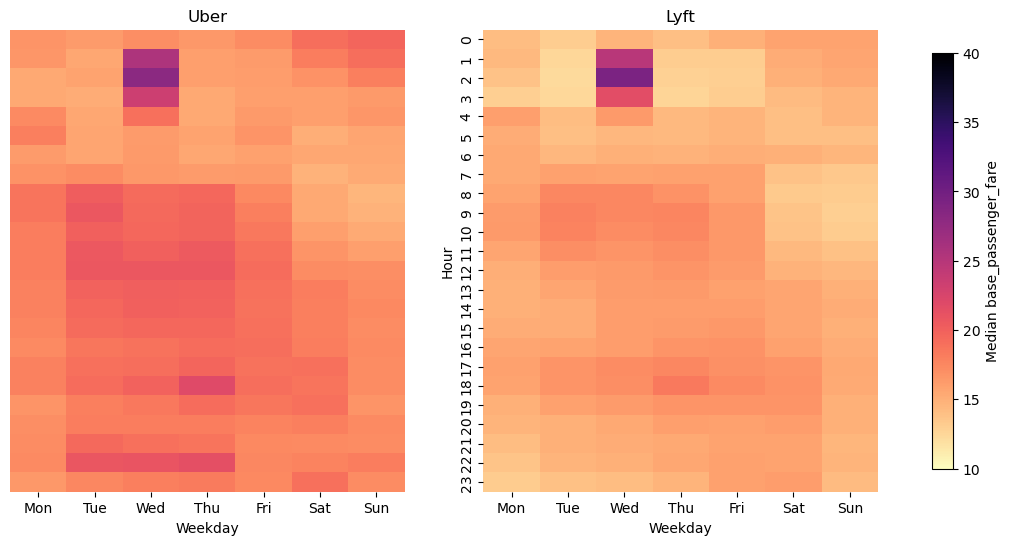

In [23]:
'''# heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[1]
ax2 = axes[0]

# lyft heatmap
heat_lyft = (
    lyft
    .groupby(["hour", "weekday"])["base_passenger_fare"]
    .median()
    .unstack())
heat_lyft.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print(heat_lyft.min().min())
#plt.figure(figsize=(14, 5))
sns.heatmap(
    heat_lyft,
    cmap = "magma_r",
    cbar = False,
    vmin = 10,
    vmax = 40,
    ax = ax1)
ax1.set_xlabel("Weekday")
ax1.set_ylabel("Hour")
#heat.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax1.set_title("Lyft")

# uber heatmap
heat_uber = (
    uber
    .groupby(["hour", "weekday"])["base_passenger_fare"]
    .median()
    .unstack())
heat_uber.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print(heat_uber.min().min())
#plt.figure(figsize=(14, 5))
sns.heatmap(
    heat_uber,
    cmap = "magma_r",
    cbar = False,
    vmin = 10,
    vmax = 40,
    ax = ax2)
ax2.set_xlabel("Weekday")
#ax2.set_ylabel("Hour")
ax2.set_ylabel("")
ax2.set_yticks([])
ax2.set_title("Uber")

cbar = fig.colorbar(
    axes[1].collections[0],
    ax = axes,
    location="right",
    shrink=0.9,
    label="Median base_passenger_fare"
)
plt.savefig("heat_ekon.png", dpi=300, bbox_inches="tight")
plt.show()'''